# 04 — Prepare candidate airwave events for array analysis

Construct the production candidate catalogue from the preserved Antelope manual picks after removing expected differential travel times. This notebook consumes the canonical geometry from Notebook 02 and the weather-derived provisional effective sound speed from Notebook 03.


## Processing history

The workflow began with manual candidate-airwave picking in Antelope `dbpick`.
The original picks were recovered from MATLAB/GISMO with millisecond precision.
Legacy 153- and 157-event catalogues were compared, differential-delay
correction was introduced, filtering and local-linear baseline experiments were
tested, and a centered 1.0 s moving median was adopted for unfiltered pressure
measurements. The assumed 351 m/s speed is only an initial alignment model.
The simple compression–rarefaction measurement is a morphology diagnostic, not an event-existence test. A tightly associated multi-channel candidate is retained even when a complex waveform—most notably the principal explosion—does not contain a qualifying positive-then-negative pair.


## 1. Imports and paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter
from obspy import Stream, Trace, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]
LEGACY_EXPORT_DIR = PROJECT_ROOT / "metadata" / "legacy_export"

PICK_FILE = LEGACY_EXPORT_DIR / "manual_arrival_picks.csv"
STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "candidate_airwave_preparation"
EVENT_STREAM_DIR = OUTPUT_DIR / "event_streams"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [OUTPUT_DIR, EVENT_STREAM_DIR, FIGURE_DIR, DERIVED_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BASELINE_REMOVED_STREAM_FILE = (
    DERIVED_DIR / "bchh_corrected_moving_median_baseline_removed.pkl"
)


## 2. Configuration

In [2]:
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")
SEISMIC_CHANNELS = ("HHZ", "HHN", "HHE")

ANALYSIS_CONFIG_FILE = DERIVED_DIR / "analysis_configuration.json"
GEOMETRY_FILE = DERIVED_DIR / "bchh_geometry.csv"
WEATHER_SUMMARY_FILE = (
    PROJECT_ROOT / "outputs" / "weather" / "derived"
    / "weather_acoustic_summary.csv"
)
for required_file in [ANALYSIS_CONFIG_FILE, GEOMETRY_FILE, WEATHER_SUMMARY_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
geometry = pd.read_csv(GEOMETRY_FILE)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

BCHH_INFRASOUND_DISTANCES_M = (
    geometry.loc[geometry["channel"].isin(INFRASOUND_CHANNELS)]
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
REFERENCE_CHANNEL = analysis_config["infrasound_reference_channel"]
PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)

MOVING_MEDIAN_WINDOW_S = 1.0
ASSOCIATION_WINDOW_S = 0.040
MINIMUM_CHANNEL_COUNT = 2

MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.010
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.180
PEAK_SEARCH_WINDOW_S = (-0.04, 0.25)
BOUNDARY_EXTENSION_FRACTION = 0.50

REFINE_BOUNDARIES_TO_NOISE = True
NOISE_WINDOW_S = (-0.40, -0.10)
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

SAVED_SEGMENT_PRE_S = 0.20
SAVED_SEGMENT_POST_S = 0.30

TIGHT_PICK_SPAN_S = 0.020
HIGH_SNR_THRESHOLD = 8.0
MODERATE_SNR_THRESHOLD = 4.0

WRITE_EVENT_PNGS = True


## 3. Load data

In [3]:
for required_file in [STREAM_FILE, PICK_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

st_corr = read(str(STREAM_FILE), format="PICKLE")
picks_all = pd.read_csv(PICK_FILE)

picks_all["channel"] = picks_all["channel"].astype(str).str.upper().str.strip()
picks_all["phase_normalized"] = (
    picks_all["phase"].fillna("").astype(str).str.lower().str.strip()
)
picks_all["arrival_time"] = pd.to_datetime(
    picks_all["arrivalTimeEpochS"], unit="s", utc=True
)

if "isDeleted" in picks_all.columns:
    picks_all["is_deleted"] = (
        picks_all["isDeleted"].astype(str).str.lower().isin(["true", "1"])
    )
else:
    picks_all["is_deleted"] = picks_all["phase_normalized"].eq("del")

stream_start_epoch_s = max(float(tr.stats.starttime.timestamp) for tr in st_corr)
stream_end_epoch_s = min(float(tr.stats.endtime.timestamp) for tr in st_corr)

accepted_picks = picks_all.loc[
    picks_all["channel"].isin(INFRASOUND_CHANNELS)
    & picks_all["phase_normalized"].eq("n")
    & ~picks_all["is_deleted"]
    & picks_all["arrivalTimeEpochS"].between(
        stream_start_epoch_s, stream_end_epoch_s, inclusive="both"
    )
].copy()

accepted_picks = accepted_picks.sort_values(
    ["arrivalTimeEpochS", "channel", "pickIndex"]
).reset_index(drop=True)

print(st_corr)
print("Accepted infrasound picks:", len(accepted_picks))


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Accepted infrasound picks: 384


## 4. Remove centered moving-median baseline

In [4]:
def odd_sample_count(duration_s: float, sampling_rate_hz: float) -> int:
    count = max(3, int(round(duration_s * sampling_rate_hz)))
    return count + 1 if count % 2 == 0 else count


def moving_median_baseline(
    values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_s: float,
) -> np.ndarray:
    return median_filter(
        np.asarray(values, dtype=float),
        size=odd_sample_count(window_s, sampling_rate_hz),
        mode="nearest",
    )


def remove_moving_median_baseline(
    trace: Trace,
    *,
    window_s: float,
) -> tuple[Trace, np.ndarray]:
    corrected = trace.copy()
    baseline = moving_median_baseline(
        corrected.data,
        sampling_rate_hz=float(corrected.stats.sampling_rate),
        window_s=window_s,
    )
    corrected.data = corrected.data.astype(float) - baseline
    corrected.stats.processing = list(
        getattr(corrected.stats, "processing", [])
    )
    corrected.stats.processing.append(
        f"centered moving-median baseline removed: window={window_s:g} s"
    )
    return corrected, baseline


st_baseline_removed = Stream()
baseline_arrays = {}

for trace in st_corr:
    if trace.stats.channel in INFRASOUND_CHANNELS:
        corrected_trace, baseline = remove_moving_median_baseline(
            trace, window_s=MOVING_MEDIAN_WINDOW_S
        )
        st_baseline_removed += corrected_trace
        baseline_arrays[trace.id] = baseline
    else:
        st_baseline_removed += trace.copy()

st_baseline_removed.sort()

with BASELINE_REMOVED_STREAM_FILE.open("wb") as file_object:
    pickle.dump(
        st_baseline_removed,
        file_object,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print(st_baseline_removed)
print("Wrote", BASELINE_REMOVED_STREAM_FILE)

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_moving_median_baseline_removed.pkl


## 5. Correct picks for provisional differential delays

In [5]:
def differential_delays_s(
    distances_m: Mapping[str, float],
    *,
    effective_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    reference_distance_m = distances_m[reference_channel]
    return {
        channel: (distance_m - reference_distance_m) / effective_speed_mps
        for channel, distance_m in distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_speed_mps=PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS,
    reference_channel=REFERENCE_CHANNEL,
)

accepted_picks["predicted_relative_delay_s"] = (
    accepted_picks["channel"].map(DIFFERENTIAL_DELAYS_S)
)
accepted_picks["reduced_pick_epoch_s"] = (
    accepted_picks["arrivalTimeEpochS"]
    - accepted_picks["predicted_relative_delay_s"]
)
accepted_picks["reduced_pick_time"] = pd.to_datetime(
    accepted_picks["reduced_pick_epoch_s"],
    unit="s",
    utc=True,
)

display(pd.DataFrame({
    "channel": list(DIFFERENTIAL_DELAYS_S),
    "distance_m": [
        BCHH_INFRASOUND_DISTANCES_M[ch] for ch in DIFFERENTIAL_DELAYS_S
    ],
    "relative_delay_s": list(DIFFERENTIAL_DELAYS_S.values()),
}))

,channel,distance_m,relative_delay_s
0,HD1,1438.029446,0.090329
1,HD2,1406.325899,0.000000
2,HD3,1410.854982,0.012904


## 6. Associate reduced-time picks

In [6]:
def associate_reduced_time_picks(
    picks: pd.DataFrame,
    *,
    association_window_s: float,
    minimum_channel_count: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = picks.sort_values(
        ["reduced_pick_epoch_s", "channel", "pickIndex"]
    ).copy()

    work["candidate_event_number"] = 0
    work["association_status"] = "unassigned"
    work["association_residual_s"] = np.nan

    event_rows = []
    remaining = set(work.index)
    next_event_number = 1

    while remaining:
        seed_index = min(
            remaining,
            key=lambda index: (
                work.at[index, "reduced_pick_epoch_s"],
                work.at[index, "pickIndex"],
            ),
        )
        seed_time_s = float(work.at[seed_index, "reduced_pick_epoch_s"])

        candidate_indices = [
            index
            for index in remaining
            if 0.0
            <= work.at[index, "reduced_pick_epoch_s"] - seed_time_s
            <= association_window_s
        ]

        candidates = work.loc[candidate_indices].copy()
        candidates["distance_from_seed_s"] = (
            candidates["reduced_pick_epoch_s"] - seed_time_s
        ).abs()

        selected = (
            candidates.sort_values(
                ["channel", "distance_from_seed_s", "pickIndex"]
            )
            .drop_duplicates("channel", keep="first")
        )

        if selected["channel"].nunique() >= minimum_channel_count:
            center_time_s = float(selected["reduced_pick_epoch_s"].median())
            selected_indices = list(selected.index)

            work.loc[selected_indices, "candidate_event_number"] = (
                next_event_number
            )
            work.loc[selected_indices, "association_status"] = "associated"
            work.loc[selected_indices, "association_residual_s"] = (
                work.loc[selected_indices, "reduced_pick_epoch_s"]
                - center_time_s
            )

            event_rows.append({
                "candidate_event_number": next_event_number,
                "reduced_event_epoch_s": center_time_s,
                "first_reduced_pick_epoch_s": float(
                    selected["reduced_pick_epoch_s"].min()
                ),
                "last_reduced_pick_epoch_s": float(
                    selected["reduced_pick_epoch_s"].max()
                ),
                "corrected_pick_span_s": float(
                    selected["reduced_pick_epoch_s"].max()
                    - selected["reduced_pick_epoch_s"].min()
                ),
                "pick_count": len(selected),
                "channel_count": int(selected["channel"].nunique()),
                "channels": ",".join(sorted(selected["channel"].unique())),
                "pick_indices": ",".join(
                    selected["pickIndex"].astype(int).astype(str)
                ),
            })

            remaining.difference_update(selected_indices)
            next_event_number += 1
        else:
            work.at[seed_index, "association_status"] = "unassociated_seed"
            remaining.remove(seed_index)

    events = pd.DataFrame(event_rows)
    events["reduced_event_time"] = pd.to_datetime(
        events["reduced_event_epoch_s"], unit="s", utc=True
    )
    return work, events


assigned_picks, candidate_events = associate_reduced_time_picks(
    accepted_picks,
    association_window_s=ASSOCIATION_WINDOW_S,
    minimum_channel_count=MINIMUM_CHANNEL_COUNT,
)

print("Candidate events:", len(candidate_events))
print(candidate_events["channel_count"].value_counts().sort_index())

Candidate events: 154
channel_count
2    91
3    63
Name: count, dtype: int64


## 7. Shift waveform timing to the HD2 reference

In [7]:
def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(trace: Trace, delay_s: float) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted


def extract_shifted_event_arrays(
    event_epoch_s: float,
    *,
    stream: Stream,
    pre_s: float,
    post_s: float,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = shift_trace_to_reference(
            select_one_trace(stream, channel),
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - pre_s),
            UTCDateTime(event_epoch_s + post_s),
            pad=False,
        )
        shifted_traces[channel] = trace

    rates = {float(tr.stats.sampling_rate) for tr in shifted_traces.values()}
    if len(rates) != 1:
        raise ValueError("Inconsistent infrasound sample rates")
    sampling_rate_hz = rates.pop()

    common_start_s = max(
        float(tr.stats.starttime.timestamp) for tr in shifted_traces.values()
    )
    common_end_s = min(
        float(tr.stats.endtime.timestamp) for tr in shifted_traces.values()
    )

    npts = int(np.floor(
        (common_end_s - common_start_s) * sampling_rate_hz
    )) + 1
    epoch_grid_s = common_start_s + np.arange(npts) / sampling_rate_hz
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}
    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts) / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays, sampling_rate_hz

## 8. Measure pulse morphology

In [8]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - center))


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )
    best = None

    for positive_index in indices:
        positive_value = values[positive_index]
        if not np.isfinite(positive_value) or positive_value <= 0:
            continue

        positive_time_s = times_s[positive_index]
        negative_candidates = indices[
            (times_s[indices] >= positive_time_s + minimum_lag_s)
            & (times_s[indices] <= positive_time_s + maximum_lag_s)
        ]
        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if not np.isfinite(negative_value) or negative_value >= 0:
            continue

        peak_to_peak_pa = positive_value - negative_value
        if best is None or peak_to_peak_pa > best["peak_to_peak_pa"]:
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(times_s[negative_index]),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak_pa),
                "positive_negative_lag_s": float(
                    times_s[negative_index] - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }
    return best


def estimate_event_boundaries(
    values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
) -> dict:
    lag_s = pair["positive_negative_lag_s"]
    start_s = pair["positive_time_s"] - BOUNDARY_EXTENSION_FRACTION * lag_s
    end_s = pair["negative_time_s"] + BOUNDARY_EXTENSION_FRACTION * lag_s

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    noise_scale_pa = robust_noise_scale(values[noise_mask])
    return {
        "event_start_s": start_s,
        "event_end_s": end_s,
        "event_duration_s": end_s - start_s,
        "noise_scale_pa": noise_scale_pa,
    }


def robust_peak_snr(
    values: np.ndarray,
    times_s: np.ndarray,
    start_s: float,
    end_s: float,
    noise_scale_pa: float,
) -> float:
    signal_mask = (times_s >= start_s) & (times_s <= end_s)
    if noise_scale_pa <= 0 or not np.any(signal_mask):
        return np.nan
    return float(
        np.nanmax(np.abs(values[signal_mask])) / noise_scale_pa
    )


measurement_rows = []
waveform_cache = {}

for event in candidate_events.itertuples(index=False):
    event_number = int(event.candidate_event_number)
    event_epoch_s = float(event.reduced_event_epoch_s)

    times_s, arrays, sampling_rate_hz = extract_shifted_event_arrays(
        event_epoch_s,
        stream=st_baseline_removed,
        pre_s=0.50,
        post_s=0.60,
    )

    median_stack = np.nanmedian(
        np.vstack([arrays[ch] for ch in INFRASOUND_CHANNELS]),
        axis=0,
    )

    pair = find_positive_negative_pair(
        median_stack,
        times_s,
        search_window_s=PEAK_SEARCH_WINDOW_S,
        minimum_lag_s=MINIMUM_POSITIVE_NEGATIVE_LAG_S,
        maximum_lag_s=MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    )

    if pair["valid_pair"]:
        bounds = estimate_event_boundaries(median_stack, times_s, pair)
        snr = robust_peak_snr(
            median_stack,
            times_s,
            bounds["event_start_s"],
            bounds["event_end_s"],
            bounds["noise_scale_pa"],
        )
        valid_measurement = True
        failure_reason = ""
    else:
        bounds = {
            "event_start_s": np.nan,
            "event_end_s": np.nan,
            "event_duration_s": np.nan,
            "noise_scale_pa": np.nan,
        }
        snr = np.nan
        valid_measurement = False
        failure_reason = "no positive-before-negative pair"

    measurement_rows.append({
        "candidate_event_number": event_number,
        "valid_measurement": valid_measurement,
        "failure_reason": failure_reason,
        "median_stack_snr": snr,
        **pair,
        **bounds,
    })

    waveform_cache[event_number] = {
        "times_s": times_s,
        "arrays": arrays,
        "median_stack": median_stack,
    }

event_measurements = pd.DataFrame(measurement_rows)
candidate_events = candidate_events.merge(
    event_measurements,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

## 9. Assign descriptive quality classes

In [9]:
def classify_candidate_event(row: pd.Series) -> str:
    if not bool(row["valid_measurement"]):
        return "D_complex_or_noncanonical_waveform"
    if (
        row["channel_count"] == 3
        and row["corrected_pick_span_s"] <= TIGHT_PICK_SPAN_S
        and row["median_stack_snr"] >= HIGH_SNR_THRESHOLD
    ):
        return "A_robust_impulsive"
    if (
        row["channel_count"] >= 2
        and row["median_stack_snr"] >= MODERATE_SNR_THRESHOLD
    ):
        return "B_probable_event"
    if row["channel_count"] >= 2 and row["valid_pair"]:
        return "C_weak_coherent_candidate"
    return "D_complex_or_noncanonical_waveform"


candidate_events["quality_class"] = candidate_events.apply(
    classify_candidate_event,
    axis=1,
)

display(candidate_events["quality_class"].value_counts())


quality_class
B_probable_event                      82
A_robust_impulsive                    46
C_weak_coherent_candidate             25
D_complex_or_noncanonical_waveform     1
Name: count, dtype: int64

## 10. Save fixed Stream segments and metadata

In [10]:
index_rows = []

for event in candidate_events.itertuples(index=False):
    event_number = int(event.candidate_event_number)
    center_epoch_s = float(event.reduced_event_epoch_s)

    segment_start_s = center_epoch_s - SAVED_SEGMENT_PRE_S
    segment_end_s = center_epoch_s + SAVED_SEGMENT_POST_S

    segment = st_baseline_removed.copy().trim(
        UTCDateTime(segment_start_s),
        UTCDateTime(segment_end_s),
        pad=False,
    )

    filename = f"candidate_event_{event_number:03d}.pkl"
    path = EVENT_STREAM_DIR / filename

    with path.open("wb") as file_object:
        pickle.dump(
            segment,
            file_object,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    index_rows.append({
        "candidate_event_number": event_number,
        "segment_file": filename,
        "segment_path": str(path),
        "segment_start_epoch_s": segment_start_s,
        "segment_end_epoch_s": segment_end_s,
    })

event_stream_index = pd.DataFrame(index_rows)
candidate_events = candidate_events.merge(
    event_stream_index,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

assigned_picks.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_pick_assignments.csv",
    index=False,
)
candidate_events.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_airwave_event_catalogue.csv",
    index=False,
)
event_stream_index.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_stream_index.csv",
    index=False,
)
assigned_picks.loc[
    assigned_picks["association_status"] != "associated"
].to_csv(
    DERIVED_OUTPUT_DIR / "unassociated_accepted_infrasound_picks.csv",
    index=False,
)

metadata = {
    "analysis_configuration_file": str(ANALYSIS_CONFIG_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "weather_summary_file": str(WEATHER_SUMMARY_FILE),
    "moving_median_window_s": MOVING_MEDIAN_WINDOW_S,
    "provisional_effective_acoustic_speed_mps": (
        PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS
    ),
    "reference_channel": REFERENCE_CHANNEL,
    "differential_delays_s": DIFFERENTIAL_DELAYS_S,
    "association_window_s": ASSOCIATION_WINDOW_S,
    "minimum_channel_count": MINIMUM_CHANNEL_COUNT,
    "minimum_positive_negative_lag_s": MINIMUM_POSITIVE_NEGATIVE_LAG_S,
    "maximum_positive_negative_lag_s": MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    "saved_segment_pre_s": SAVED_SEGMENT_PRE_S,
    "saved_segment_post_s": SAVED_SEGMENT_POST_S,
}

(DERIVED_OUTPUT_DIR / "candidate_event_processing_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

print("Saved", len(event_stream_index), "candidate-event Streams")


Saved 154 candidate-event Streams


## 11. Diagnostic figures

In [11]:
def build_candidate_event_figure(event_number: int):
    row = candidate_events.loc[
        candidate_events["candidate_event_number"] == event_number
    ].iloc[0]
    cached = waveform_cache[event_number]

    fig, axes = plt.subplots(
        4, 1, figsize=(10.0, 8.0), sharex=True, constrained_layout=True
    )

    for axis, channel in zip(axes[:3], INFRASOUND_CHANNELS):
        axis.plot(cached["times_s"], cached["arrays"][channel], linewidth=0.95)
        axis.axhline(0.0, linewidth=0.55, alpha=0.55)
        axis.axvline(0.0, linewidth=0.7, alpha=0.7)
        axis.text(
            0.015, 0.84, channel,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.grid(True, axis="x", alpha=0.25)

    axes[3].plot(
        cached["times_s"],
        cached["median_stack"],
        linewidth=1.1,
    )
    axes[3].axhline(0.0, linewidth=0.55, alpha=0.55)
    axes[3].axvline(0.0, linewidth=0.7, alpha=0.7)
    axes[3].text(
        0.015, 0.84, "Median stack",
        transform=axes[3].transAxes,
        fontweight="bold",
        va="top",
    )
    axes[3].grid(True, axis="x", alpha=0.25)

    if bool(row["valid_measurement"]):
        for axis in axes:
            axis.axvspan(
                row["event_start_s"],
                row["event_end_s"],
                alpha=0.08,
            )
        axes[3].scatter(
            [row["positive_time_s"]],
            [row["positive_peak_pa"]],
            s=52,
            zorder=6,
        )
        axes[3].scatter(
            [row["negative_time_s"]],
            [row["negative_peak_pa"]],
            s=52,
            zorder=6,
        )

    for pick in assigned_picks.loc[
        assigned_picks["candidate_event_number"] == event_number
    ].itertuples(index=False):
        axis = axes[INFRASOUND_CHANNELS.index(pick.channel)]
        axis.axvline(
            pick.reduced_pick_epoch_s - row["reduced_event_epoch_s"],
            linestyle=":",
            linewidth=0.9,
        )

    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Provisional reduced time relative to candidate event (s)"
    )

    fig.suptitle(
        f"Candidate event {event_number:03d}: {row['quality_class']}\n"
        f"channels {row['channels']}; corrected pick span "
        f"{row['corrected_pick_span_s']:.3f} s; "
        f"median-stack SNR {row['median_stack_snr']:.1f}",
        fontweight="bold",
    )
    return fig


if WRITE_EVENT_PNGS:
    for index, event_number in enumerate(
        candidate_events["candidate_event_number"].astype(int),
        start=1,
    ):
        figure = build_candidate_event_figure(event_number)
        figure.savefig(
            FIGURE_DIR / f"candidate_event_{event_number:03d}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(figure)

        if index == 1 or index % 20 == 0 or index == len(candidate_events):
            print(f"Generated {index} of {len(candidate_events)} figures")

Generated 1 of 154 figures
Generated 20 of 154 figures
Generated 40 of 154 figures
Generated 60 of 154 figures
Generated 80 of 154 figures
Generated 100 of 154 figures
Generated 120 of 154 figures
Generated 140 of 154 figures
Generated 154 of 154 figures


## 12. Production summary

,candidate_event_number,reduced_event_time,channels,corrected_pick_span_s,median_stack_snr,positive_peak_pa,negative_peak_pa,positive_negative_lag_s,event_start_s,event_end_s,quality_class,segment_file
0,1,2016-09-01 13:07:15.927095890+00:00,"HD1,HD2,HD3",0.002329,25.903096,33.832002,-18.375681,0.088,-0.039096,0.136904,A_robust_impulsive,candidate_event_001.pkl
1,2,2016-09-01 13:07:16.057095766+00:00,"HD1,HD2,HD3",0.011329,13.172934,22.859838,-21.205054,0.092,-0.012000,0.172000,A_robust_impulsive,candidate_event_002.pkl
2,3,2016-09-01 13:07:16.255000114+00:00,"HD1,HD2,HD3",0.003575,3.670412,37.673816,-9.892704,0.032,0.009000,0.073000,C_weak_coherent_candidate,candidate_event_003.pkl
3,4,2016-09-01 13:07:16.447047710+00:00,"HD2,HD3",0.029904,2.442449,27.896285,-8.601083,0.040,0.016952,0.096952,C_weak_coherent_candidate,candidate_event_004.pkl
4,5,2016-09-01 13:07:16.799547911+00:00,"HD2,HD3",0.000904,2.009663,13.848623,-22.909564,0.032,0.052452,0.116452,C_weak_coherent_candidate,candidate_event_005.pkl
5,6,2016-09-01 13:07:17.242000103+00:00,"HD1,HD2,HD3",0.003575,5.805097,33.684419,-19.450007,0.156,-0.044000,0.268000,B_probable_event,candidate_event_006.pkl
6,7,2016-09-01 13:07:17.634000063+00:00,"HD1,HD2,HD3",0.003425,2.198661,28.522735,-13.212843,0.052,-0.004000,0.100000,C_weak_coherent_candidate,candidate_event_007.pkl
7,8,2016-09-01 13:07:17.895095825+00:00,"HD1,HD2,HD3",0.004329,4.286676,29.778663,-21.489004,0.032,0.004904,0.068904,B_probable_event,candidate_event_008.pkl
8,9,2016-09-01 13:07:18.111095905+00:00,"HD1,HD2,HD3",0.002329,10.989767,104.482742,-74.628968,0.028,0.006904,0.062904,A_robust_impulsive,candidate_event_009.pkl
9,10,2016-09-01 13:07:18.389048100+00:00,"HD2,HD3",0.002096,1.468549,30.226281,-28.363152,0.088,0.068623,0.244623,C_weak_coherent_candidate,candidate_event_010.pkl


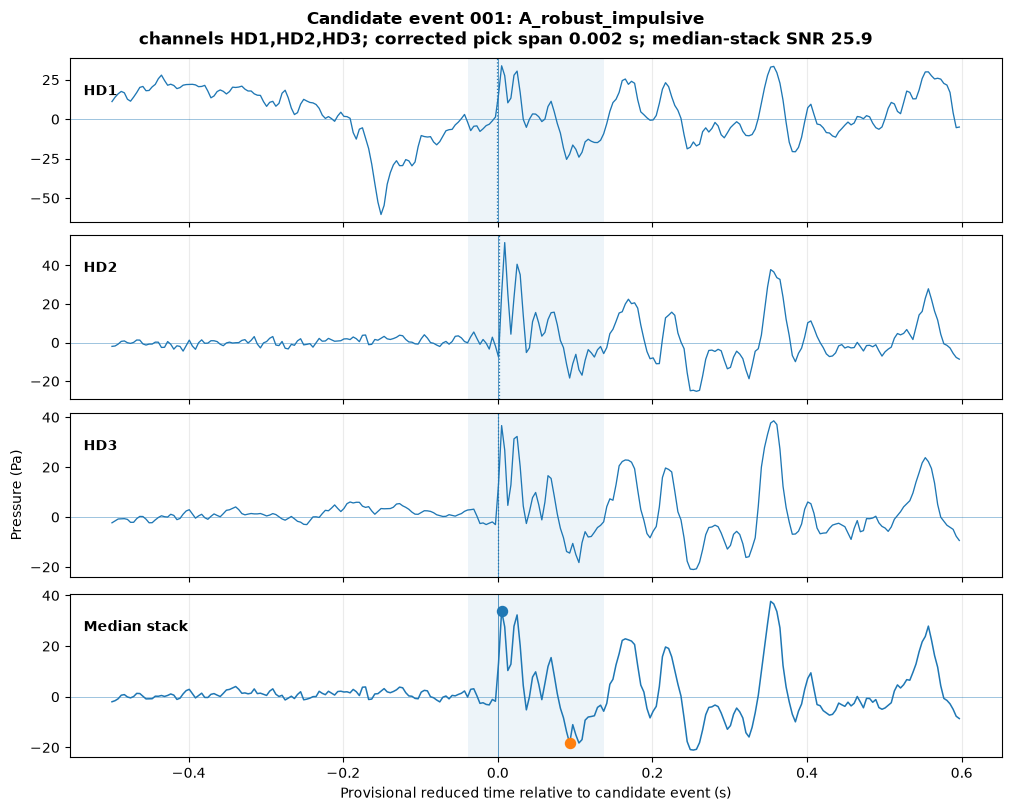

In [12]:
display(
    candidate_events[
        [
            "candidate_event_number",
            "reduced_event_time",
            "channels",
            "corrected_pick_span_s",
            "median_stack_snr",
            "positive_peak_pa",
            "negative_peak_pa",
            "positive_negative_lag_s",
            "event_start_s",
            "event_end_s",
            "quality_class",
            "segment_file",
        ]
    ].head(20)
)

PREVIEW_EVENT_NUMBER = int(
    candidate_events.iloc[0]["candidate_event_number"]
)
preview = build_candidate_event_figure(PREVIEW_EVENT_NUMBER)
plt.show()

## Production outputs

The output paths remain compatible with the downstream planar-array analysis:

```text
outputs/candidate_airwave_preparation/
    event_streams/candidate_event_001.pkl ...
    derived/candidate_airwave_event_catalogue.csv
    derived/candidate_event_pick_assignments.csv
    derived/candidate_event_stream_index.csv
    derived/unassociated_accepted_infrasound_picks.csv
    derived/candidate_event_processing_metadata.json
```
